In [8]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))


In [23]:
import torch
import numpy as np
import random

def set_seed(seed=42):
    # 1. Standardowy Python
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 2. NumPy
    np.random.seed(seed)
    
    # 3. PyTorch (CPU i GPU)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # dla systemów multi-GPU
    
    # 4. Operacje deterministyczne w PyTorch
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(15)

In [38]:
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
from sklearn.metrics import classification_report, roc_auc_score
from src.models import Eeg_GNN
from src.utils import load_data_for_subjects
from src.config import PROJECT_ROOT as ROOT_DIR


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME = "best_model.pth"
MODEL_PATH = ROOT_DIR / "models" / MODEL_NAME
SCALER_PATH = ROOT_DIR / "wyniki" / "robust_scaler_params.pt"



SUBJECTS_TEST = ['chb23', 'chb24']
test_data = load_data_for_subjects(SUBJECTS_TEST)
scaler_params = torch.load(SCALER_PATH, weights_only=True)
median = scaler_params['median']
iqr = scaler_params['iqr']

# Skalowanie danych
for g in test_data:
    g.x = (g.x - median) / iqr

test_loader = DataLoader(test_data, batch_size=64, shuffle=False)


num_features = test_data[0].num_node_features
model = Eeg_GNN(num_node_features=num_features, num_classes=2).to(DEVICE)

model.load_state_dict(torch.load(MODEL_PATH))


<All keys matched successfully>

In [39]:
model.eval()

y_prob_t = []
y_true_t, y_pred_t = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)

        out = model(batch.x, batch.edge_index, batch.batch, batch.edge_attr)
        y_pred_t.extend(out.argmax(dim=1).cpu().numpy())
        y_true_t.extend(batch.y.cpu().numpy().reshape(-1))
        probs = torch.softmax(out, dim=1).cpu().numpy()
        y_prob_t.extend(probs)


print(classification_report(y_true_t, y_pred_t, labels=[0, 1], 
                            target_names=['Non-Ictal', 'Ictal'], zero_division=0))

y_true_t = np.array(y_true_t)
y_prob_t = np.array(y_prob_t)

# Obliczanie testowego AUROC
y_true_det = y_true_t
y_score_det = y_prob_t[:, 1] # Prawdopodobieństwo klasy Ictal

test_det_auroc = roc_auc_score(y_true_det, y_score_det)
print(f"\nDetection AUROC (Non-Ictal vs Ictal): {test_det_auroc:.4f}")


              precision    recall  f1-score   support

   Non-Ictal       0.94      0.99      0.97      6846
       Ictal       0.97      0.76      0.85      1757

    accuracy                           0.95      8603
   macro avg       0.96      0.88      0.91      8603
weighted avg       0.95      0.95      0.94      8603


Detection AUROC (Non-Ictal vs Ictal): 0.9483


In [40]:
from torch_geometric.explain import Explainer, GNNExplainer

# Zakładam, że model jest już załadowany i ustawiony w tryb ewaluacji
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()

# Konfiguracja Explainera (PyTorch Geometric 2.x)
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=1000), # epoki optymalizacji maski
    explanation_type='model',           # Chcemy wyjaśnić decyzję modelu
    node_mask_type='attributes',        # Zwraca ważność poszczególnych cech (19 features)
    edge_mask_type='object',            # Zwraca ważność poszczególnych krawędzi (PLV)
    model_config=dict(
        mode='multiclass_classification',
        task_level='graph',             # Klasyfikujemy całe grafy (okna 6s), nie pojedyncze węzły
        return_type='raw',              # Twój model zwraca surowe logity (brak softmax na końcu forward)
    ),
)

In [41]:
# Znajdźmy poprawnie sklasyfikowany napad w danych testowych
target_graph = None
for g in test_data:
    if g.y.item() == 1: # Klasa Ictal
        g = g.to(DEVICE)
        out = model(g.x, g.edge_index, g.batch, edge_weight=g.edge_attr)
        pred = out.argmax(dim=1).item()
        if pred == 1: # True Positive
            target_graph = g
            break

if target_graph is None:
    print("Nie znaleziono True Positive. Wybieram jakikolwiek graf napadowy.")
    target_graph = next(g for g in test_data if g.y.item() == 1).to(DEVICE)

# Generowanie wyjaśnienia! (To potrwa kilka sekund)
explanation = explainer(
    target_graph.x, 
    target_graph.edge_index, 
    batch=target_graph.batch, 
    edge_weight=target_graph.edge_attr
)

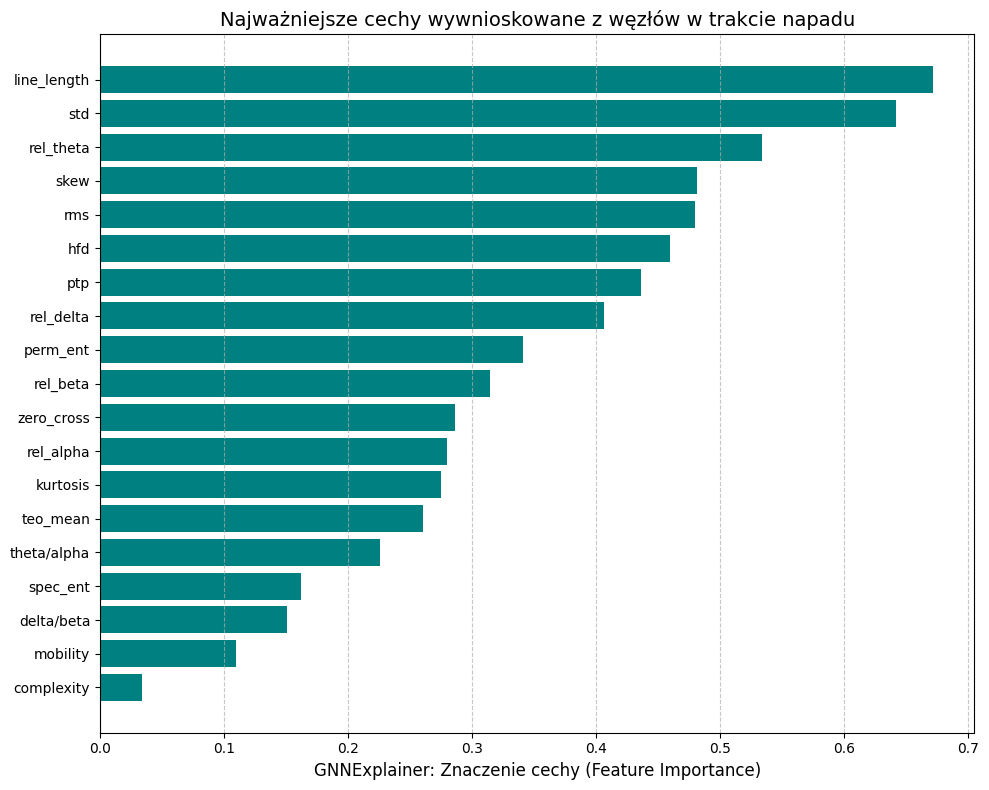

<Figure size 640x480 with 0 Axes>

In [42]:
# 1. Pobieramy maskę cech (wartości od 0 do 1)
node_mask = explanation.node_mask.cpu().numpy() # (N, 19)

# 2. Uśredniamy po wszystkich węzłach (kanałach), aby uzyskać globalną ważność
global_feature_importance = node_mask.mean(axis=0)

feature_names = ['std', 'rms', 'line_length', 'mobility', 'complexity', 'skew', 'kurtosis', 
                 'ptp', 'zero_cross', 'hfd', 'teo_mean', 'rel_delta', 'rel_theta', 
                 'rel_alpha', 'rel_beta', 'theta/alpha', 'delta/beta', 'perm_ent', 'spec_ent']

# Sortowanie do wykresu
sorted_idx = np.argsort(global_feature_importance)
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importance = global_feature_importance[sorted_idx]

# 3. Rysujemy piękny wykres bar plot
plt.figure(figsize=(10, 8))
plt.barh(sorted_features, sorted_importance, color='teal')
plt.xlabel("GNNExplainer: Znaczenie cechy (Feature Importance)", fontsize=12)
plt.title("Najważniejsze cechy wywnioskowane z węzłów w trakcie napadu", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.savefig(ROOT_DIR / "wyniki" / "gnn_explainer_feature_importance.png")

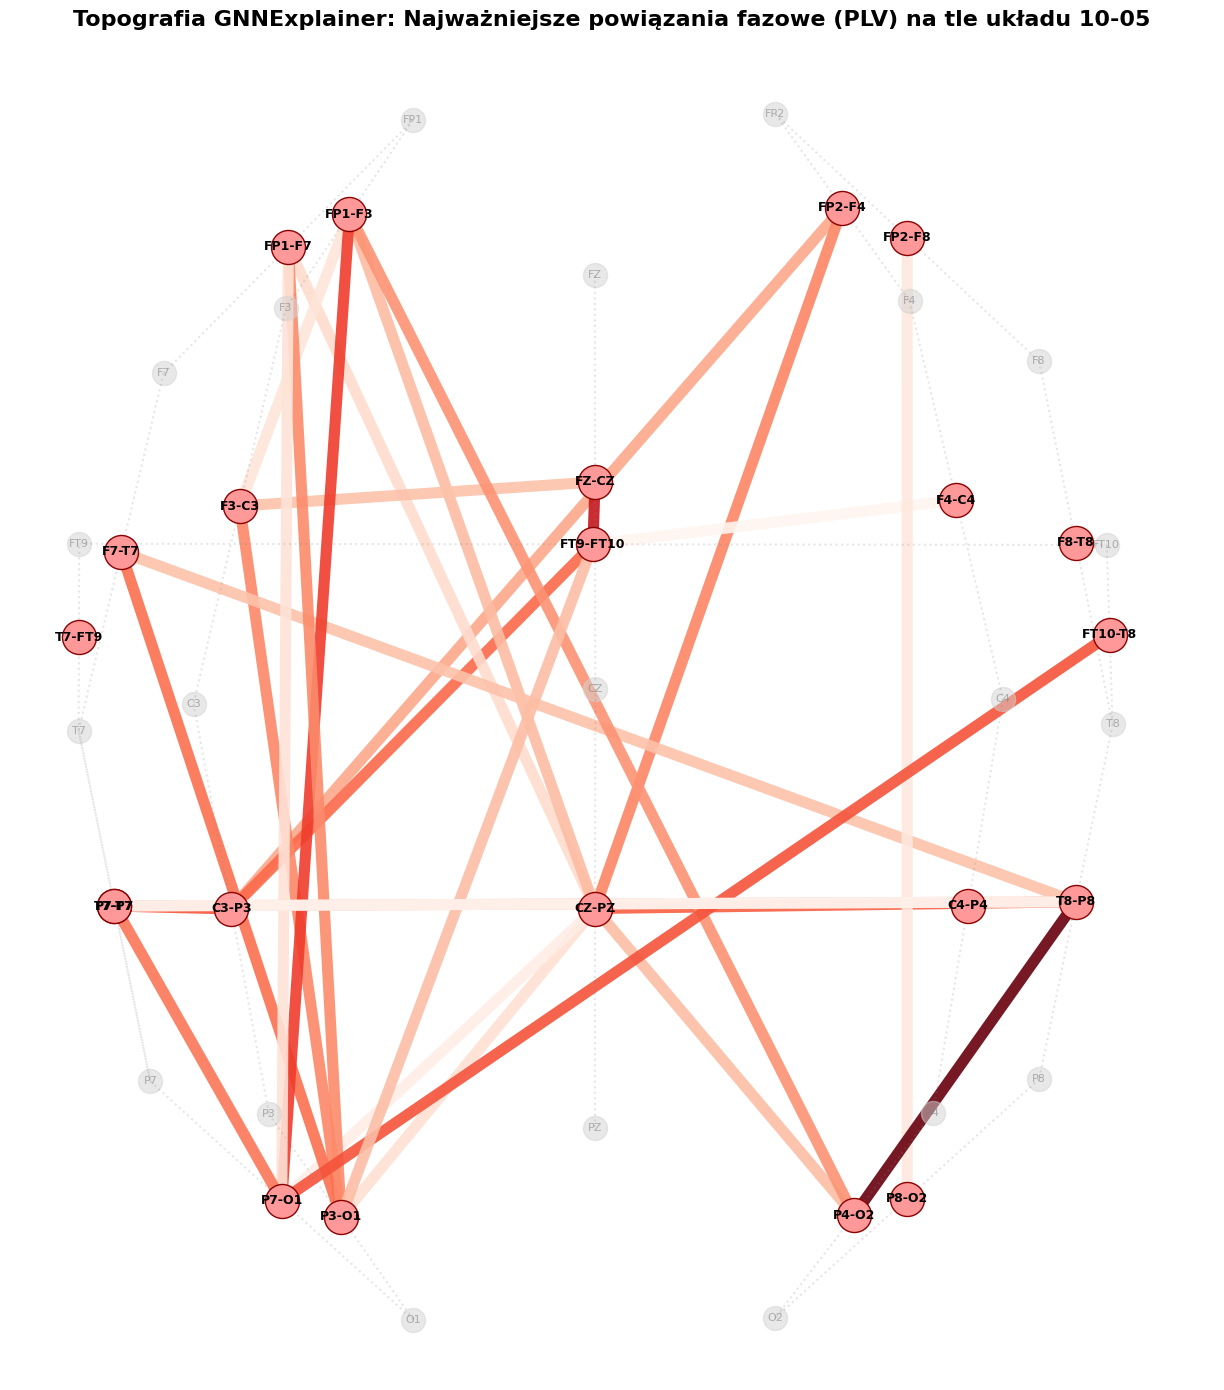

<Figure size 640x480 with 0 Axes>

In [43]:
import mne
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from src.config import COMMON_CHANNELS
# ---------------------------------------------------
# KROK 1-3: TWOJE POZYCJONOWANIE Z MNE
# ---------------------------------------------------
# (Zakładam, że masz już zdefiniowane CHANNELS / COMMON_CHANNELS
# i odpowiadają one indeksom węzłów w target_graph)

montage = mne.channels.make_standard_montage('standard_1005')
positions_3d = montage.get_positions()['ch_pos']

# Dodanie niestandardowych małych liter
positions_3d['Ft9'] = positions_3d['FT9']
positions_3d['Ft10'] = positions_3d['FT10']

needed_electrodes = set()
for ch in COMMON_CHANNELS:
    a, b = ch.split('-')
    needed_electrodes.add(a.upper())
    needed_electrodes.add(b.upper())

def normalize_mne_name(name):
    # Wyjątki dla np. FZ, CZ, PZ -> Fz, Cz, Pz
    if name.endswith('Z'):
        return name[0] + 'z'
    return name[0] + name[1:].lower()

electrode_pos = {}
for elec in needed_electrodes:
    mne_name = normalize_mne_name(elec)
    if mne_name not in positions_3d:
        # Próba alternatywnej nazwy w przypadku błędu
        mne_name = elec.upper() if elec.upper() in positions_3d else mne_name
        if mne_name not in positions_3d:
            print(f'Brak elektrody: {mne_name}')
            continue
    xyz = positions_3d[mne_name]
    electrode_pos[elec] = (xyz[0], xyz[1])

bipolar_pos = {}
for ch in COMMON_CHANNELS:
    a, b = ch.split('-')
    if a in electrode_pos and b in electrode_pos:
        pos_a = np.array(electrode_pos[a])
        pos_b = np.array(electrode_pos[b])
        bipolar_pos[ch] = tuple((pos_a + pos_b) / 2)

# ---------------------------------------------------
# KROK 4: INTEGRACJA Z GNNExplainer
# ---------------------------------------------------
# Tworzymy graf dla połączeń GNN
G_plv = nx.Graph()

# Dodajemy WĘZŁY (kanały bipolarne)
for i, ch in enumerate(COMMON_CHANNELS):
    if ch in bipolar_pos:
        G_plv.add_node(i, label=ch)

# Odfiltrowujemy tylko NAJWAŻNIEJSZE krawędzie (np. top 15%)
# edge_index i edge_mask pochodzą z wyniku GNNExplainer
edge_index_np = target_graph.edge_index.cpu().numpy()
edge_mask_np = explanation.edge_mask.cpu().numpy()

threshold = np.percentile(edge_mask_np, 85)

# Dodajemy KRAWĘDZIE do grafu PLV
for i in range(edge_index_np.shape[1]):
    src, dst = edge_index_np[0, i], edge_index_np[1, i]
    weight = edge_mask_np[i]
    if weight >= threshold and src != dst:
        G_plv.add_edge(src, dst, weight=weight)

# Mapujemy ID węzła z PyG na pozycje (x, y) z MNE
gnn_pos = {i: bipolar_pos[COMMON_CHANNELS[i]] for i in range(len(COMMON_CHANNELS)) if COMMON_CHANNELS[i] in bipolar_pos}

# ---------------------------------------------------
# KROK 5: RYSOWANIE
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 14))

# 1. TŁO: Narysuj elektrody unipolarne (bardzo blado, jako kontekst)
G_uni = nx.Graph()
G_uni.add_nodes_from(electrode_pos.keys())
nx.draw_networkx_nodes(G_uni, electrode_pos, node_color='lightgrey', node_size=300, alpha=0.5, ax=ax)
nx.draw_networkx_labels(G_uni, electrode_pos, font_size=8, font_color='grey', alpha=0.6, ax=ax)

# 2. TŁO: Pomocnicze linie między unipolarnymi a bipolarnymi
for ch in COMMON_CHANNELS:
    if ch in bipolar_pos:
        a, b = ch.split('-')
        x = [electrode_pos[a][0], bipolar_pos[ch][0], electrode_pos[b][0]]
        y = [electrode_pos[a][1], bipolar_pos[ch][1], electrode_pos[b][1]]
        ax.plot(x, y, ':', color='grey', alpha=0.2)

# 3. GŁÓWNY PUNKT: Węzły bipolarne (z GNN)
nx.draw_networkx_nodes(G_plv, gnn_pos, node_color='#ff9999', edgecolors='darkred', node_size=600, ax=ax)
labels = nx.get_node_attributes(G_plv, 'label')
nx.draw_networkx_labels(G_plv, gnn_pos, labels, font_size=9, font_weight='bold', ax=ax)

# 4. GŁÓWNY PUNKT: Krawędzie PLV z GNNExplainera
edges = G_plv.edges()
weights = [G_plv[u][v]['weight'] for u, v in edges]

if weights: # Zapobiega błędom, jeśli próg jest za wysoki i nie ma krawędzi
    max_weight = max(weights)
    normalized_widths = [(w / max_weight) * 8 for w in weights] # Grubości linii do 8px
    
    nx.draw_networkx_edges(G_plv, gnn_pos, edgelist=edges, width=normalized_widths, 
                           edge_color=weights, edge_cmap=plt.cm.Reds, alpha=0.9, ax=ax)

ax.set_title("Topografia GNNExplainer: Najważniejsze powiązania fazowe (PLV) na tle układu 10-05", 
             fontsize=16, fontweight='bold', pad=20)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.show()
plt.savefig(ROOT_DIR / "wyniki" / "gnn_explainer_topography.png")

# Testowanie kolejnych próbek napadowych

In [30]:
# Znajdźmy poprawnie sklasyfikowany napad w danych testowych
target_graph = None
counter = 0
for g in test_data:
    if g.y.item() == 1: # Klasa Ictal
        counter += 1
        if counter != 2:
            continue
        else:
            print(f"Znalazłem {counter} napad, sprawdzam klasyfikację...")
        g = g.to(DEVICE)
        out = model(g.x, g.edge_index, g.batch, edge_weight=g.edge_attr)
        pred = out.argmax(dim=1).item()
        if pred == 1: # True Positive
            target_graph = g
            break

if target_graph is None:
    print("Nie znaleziono True Positive. Wybieram jakikolwiek graf napadowy.")
    target_graph = next(g for g in test_data if g.y.item() == 1).to(DEVICE)

# Generowanie wyjaśnienia! (To potrwa kilka sekund)
explanation2 = explainer(
    target_graph.x, 
    target_graph.edge_index, 
    batch=target_graph.batch, 
    edge_weight=target_graph.edge_attr
)

Znalazłem 2 napad, sprawdzam klasyfikację...


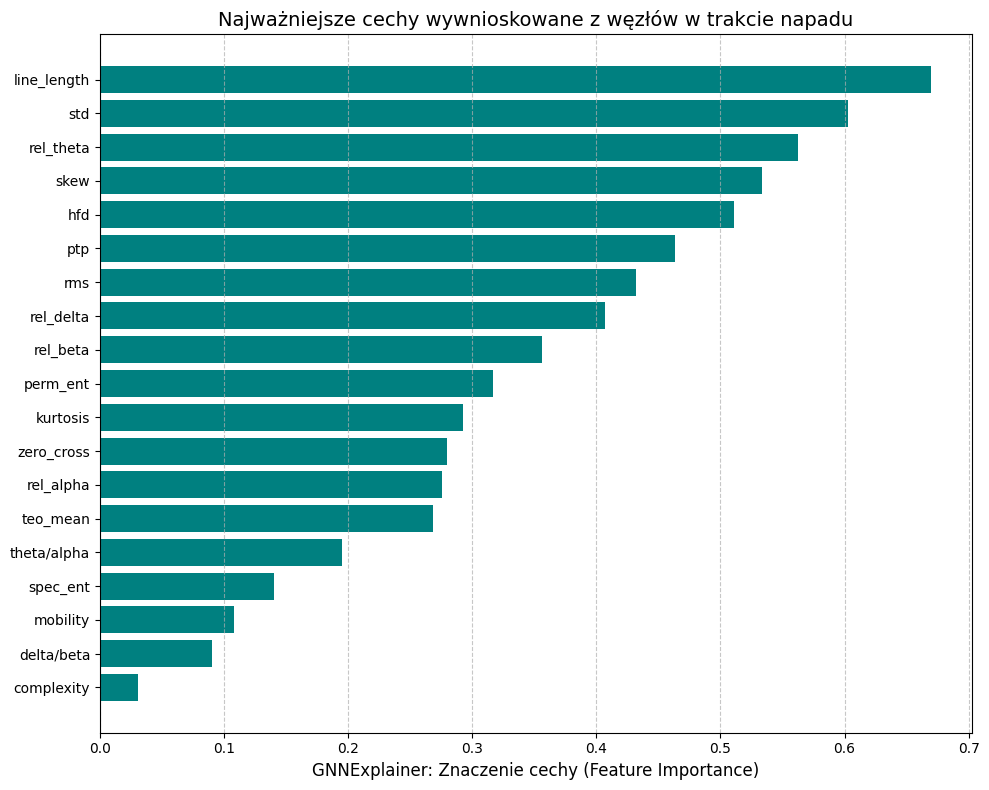

In [31]:
# 1. Pobieramy maskę cech (wartości od 0 do 1)
node_mask = explanation2.node_mask.cpu().numpy() # (N, 19)

# 2. Uśredniamy po wszystkich węzłach (kanałach), aby uzyskać globalną ważność
global_feature_importance = node_mask.mean(axis=0)

feature_names = ['std', 'rms', 'line_length', 'mobility', 'complexity', 'skew', 'kurtosis', 
                 'ptp', 'zero_cross', 'hfd', 'teo_mean', 'rel_delta', 'rel_theta', 
                 'rel_alpha', 'rel_beta', 'theta/alpha', 'delta/beta', 'perm_ent', 'spec_ent']

# Sortowanie do wykresu
sorted_idx = np.argsort(global_feature_importance)
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importance = global_feature_importance[sorted_idx]

# 3. Rysujemy piękny wykres bar plot
plt.figure(figsize=(10, 8))
plt.barh(sorted_features, sorted_importance, color='teal')
plt.xlabel("GNNExplainer: Znaczenie cechy (Feature Importance)", fontsize=12)
plt.title("Najważniejsze cechy wywnioskowane z węzłów w trakcie napadu", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

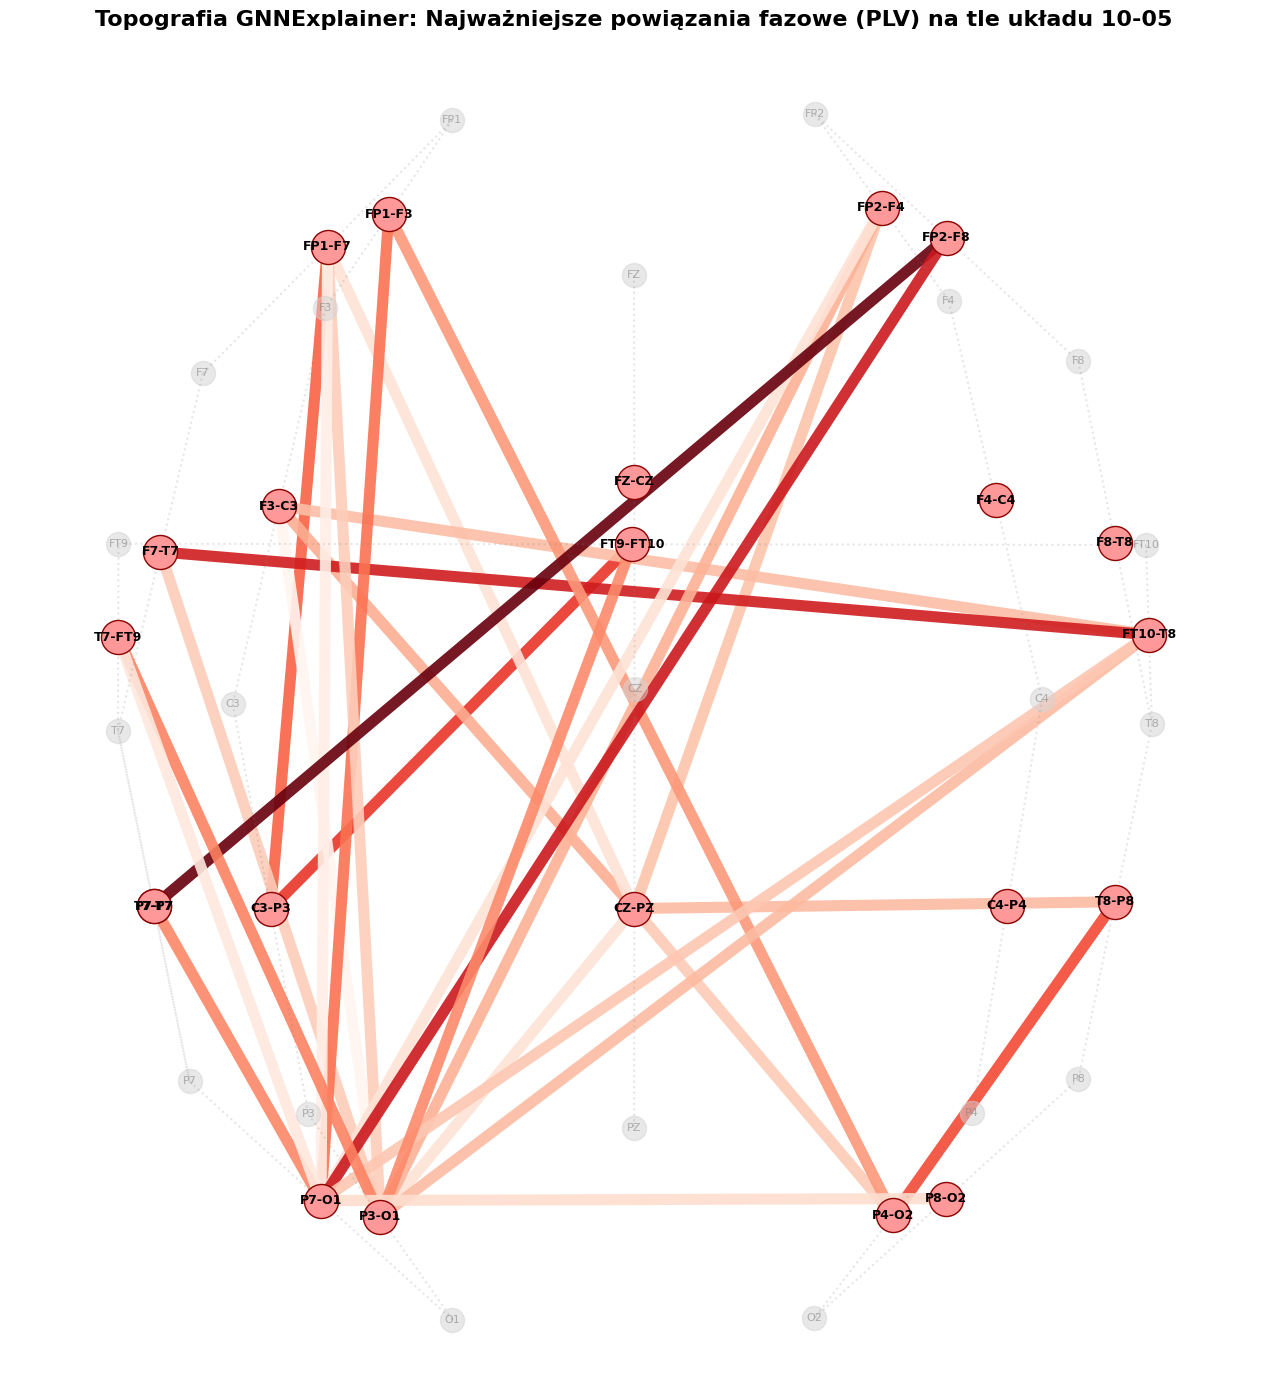

In [32]:
# ---------------------------------------------------
# KROK 4: INTEGRACJA Z GNNExplainer
# ---------------------------------------------------
# Tworzymy graf dla połączeń GNN
G_plv = nx.Graph()

# Dodajemy WĘZŁY (kanały bipolarne)
for i, ch in enumerate(COMMON_CHANNELS):
    if ch in bipolar_pos:
        G_plv.add_node(i, label=ch)

# Odfiltrowujemy tylko NAJWAŻNIEJSZE krawędzie (np. top 15%)
# edge_index i edge_mask pochodzą z wyniku GNNExplainer
edge_index_np = target_graph.edge_index.cpu().numpy()
edge_mask_np = explanation2.edge_mask.cpu().numpy()

threshold = np.percentile(edge_mask_np, 85)

# Dodajemy KRAWĘDZIE do grafu PLV
for i in range(edge_index_np.shape[1]):
    src, dst = edge_index_np[0, i], edge_index_np[1, i]
    weight = edge_mask_np[i]
    if weight >= threshold and src != dst:
        G_plv.add_edge(src, dst, weight=weight)

# Mapujemy ID węzła z PyG na pozycje (x, y) z MNE
gnn_pos = {i: bipolar_pos[COMMON_CHANNELS[i]] for i in range(len(COMMON_CHANNELS)) if COMMON_CHANNELS[i] in bipolar_pos}

# ---------------------------------------------------
# KROK 5: RYSOWANIE
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 14))

# 1. TŁO: Narysuj elektrody unipolarne (bardzo blado, jako kontekst)
G_uni = nx.Graph()
G_uni.add_nodes_from(electrode_pos.keys())
nx.draw_networkx_nodes(G_uni, electrode_pos, node_color='lightgrey', node_size=300, alpha=0.5, ax=ax)
nx.draw_networkx_labels(G_uni, electrode_pos, font_size=8, font_color='grey', alpha=0.6, ax=ax)

# 2. TŁO: Pomocnicze linie między unipolarnymi a bipolarnymi
for ch in COMMON_CHANNELS:
    if ch in bipolar_pos:
        a, b = ch.split('-')
        x = [electrode_pos[a][0], bipolar_pos[ch][0], electrode_pos[b][0]]
        y = [electrode_pos[a][1], bipolar_pos[ch][1], electrode_pos[b][1]]
        ax.plot(x, y, ':', color='grey', alpha=0.2)

# 3. GŁÓWNY PUNKT: Węzły bipolarne (z GNN)
nx.draw_networkx_nodes(G_plv, gnn_pos, node_color='#ff9999', edgecolors='darkred', node_size=600, ax=ax)
labels = nx.get_node_attributes(G_plv, 'label')
nx.draw_networkx_labels(G_plv, gnn_pos, labels, font_size=9, font_weight='bold', ax=ax)

# 4. GŁÓWNY PUNKT: Krawędzie PLV z GNNExplainera
edges = G_plv.edges()
weights = [G_plv[u][v]['weight'] for u, v in edges]

if weights: # Zapobiega błędom, jeśli próg jest za wysoki i nie ma krawędzi
    max_weight = max(weights)
    normalized_widths = [(w / max_weight) * 8 for w in weights] # Grubości linii do 8px
    
    nx.draw_networkx_edges(G_plv, gnn_pos, edgelist=edges, width=normalized_widths, 
                           edge_color=weights, edge_cmap=plt.cm.Reds, alpha=0.9, ax=ax)

ax.set_title("Topografia GNNExplainer: Najważniejsze powiązania fazowe (PLV) na tle układu 10-05", 
             fontsize=16, fontweight='bold', pad=20)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.show()

In [46]:
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import torch

# Konfiguracja Explainera (PyTorch Geometric 2.x)
explainer2 = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200), # 200 epok optymalizacji maski to standard
    explanation_type='model',           # Chcemy wyjaśnić decyzję modelu
    node_mask_type='attributes',        # Zwraca ważność poszczególnych cech (19 features)
    edge_mask_type=None,            # Zwraca ważność poszczególnych krawędzi (PLV)
    model_config=dict(
        mode='multiclass_classification',
        task_level='graph',             # Klasyfikujemy całe grafy (okna 6s), nie pojedyncze węzły
        return_type='raw',              # Twój model zwraca surowe logity (brak softmax na końcu forward)
    ),
)


# ==========================================
# FUNKCJA RATUNKOWA (Czyszczenie modelu)
# ==========================================
def cleanup_explain_state(model):
    """
    Usuwa pozostałości po GNNExplainerze z warstw modelu.
    Przywraca model do normalnego stanu forward pass.
    """
    for module in model.modules():
        if hasattr(module, 'explain'):
            module.explain = False
        if hasattr(module, '_edge_mask'):
            module._edge_mask = None

# ==========================================
# WŁAŚCIWA PĘTLA
# ==========================================
tp_importances = []
tn_importances = []

tp_count, tn_count = 0, 0
TARGET_SAMPLES = 20 

shuffled_test_data = random.sample(list(test_data), len(test_data))

for g in tqdm(shuffled_test_data, desc="Generowanie wyjaśnień"):
    if tp_count >= TARGET_SAMPLES and tn_count >= TARGET_SAMPLES: 
        break
    
    g = g.to(DEVICE)
    
    if hasattr(g, 'batch') and g.batch is None:
        g.batch = torch.zeros(g.num_nodes, dtype=torch.long, device=DEVICE)
        
    # Upewniamy się, że model jest czysty przed standardową predykcją
    cleanup_explain_state(model)
    
    # 1. Zwykła predykcja
    out = model(g.x, g.edge_index, g.batch, edge_weight=g.edge_attr)
    pred = out.argmax(dim=1).item()
    true_label = g.y.item()
    
    # 2. Wyjaśnialność (Tylko napady)
    if true_label == 1:
        try:
            # # Puszczamy explainera
            # explanation = explainer2(g.x, g.edge_index, batch=g.batch, edge_weight=g.edge_attr)
            # global_feat_imp = explanation.node_mask.cpu().numpy().mean(axis=0)
            
            if pred == 1 and tp_count < TARGET_SAMPLES: 
                print(f"TP: {tp_count}, TN: {tn_count}")

                # Puszczamy explainera
                explanation = explainer2(g.x, g.edge_index, batch=g.batch, edge_weight=g.edge_attr)
                global_feat_imp = explanation.node_mask.cpu().numpy().mean(axis=0)

                tp_importances.append(global_feat_imp)
                tp_count += 1
                                
        except AssertionError:
            # GNNExplainer się wywalił przez ChebConv. 
            # Czyścimy zainfekowany model i idziemy dalej!
            cleanup_explain_state(model)
            continue
        except Exception as e:
            cleanup_explain_state(model)
            continue

    if true_label == 0:
        try:
            if pred == 0 and tn_count < TARGET_SAMPLES: 
                print(f"TP: {tp_count}, TN: {tn_count}")

                # Puszczamy explainera
                explanation = explainer2(g.x, g.edge_index, batch=g.batch, edge_weight=g.edge_attr)
                global_feat_imp = explanation.node_mask.cpu().numpy().mean(axis=0)


                tn_importances.append(global_feat_imp)
                tn_count += 1
                
        except AssertionError:
            # GNNExplainer się wywalił przez ChebConv. 
            # Czyścimy zainfekowany model i idziemy dalej!
            cleanup_explain_state(model)
            continue
        except Exception as e:
            cleanup_explain_state(model)
            continue

print(f"\nUdało się zebrać: {tp_count} TP oraz {tn_count} TN.")

# ... [tutaj reszta kodu z rysowaniem boxplotów z poprzedniej wiadomości] ...

# Przygotowanie danych do Seaborn
data = []
for feats in tp_importances:
    for i, imp in enumerate(feats):
        data.append({'Feature': feature_names[i], 'Importance': imp, 'Typ decyzji': 'True Positive (Wykryte)'})
for feats in tn_importances:
    for i, imp in enumerate(feats):
        data.append({'Feature': feature_names[i], 'Importance': imp, 'Typ decyzji': 'True Negative'})

df = pd.DataFrame(data)

Generowanie wyjaśnień:   0%|          | 0/8603 [00:00<?, ?it/s]

TP: 0, TN: 0


Generowanie wyjaśnień:   0%|          | 1/8603 [00:04<10:04:03,  4.21s/it]

TP: 0, TN: 1


Generowanie wyjaśnień:   0%|          | 2/8603 [00:08<10:22:53,  4.35s/it]

...

TP: 18, TN: 20


Generowanie wyjaśnień:   1%|▏         | 121/8603 [02:46<1:35:45,  1.48it/s]

TP: 19, TN: 20


Generowanie wyjaśnień:   2%|▏         | 133/8603 [02:48<2:59:02,  1.27s/it]


Udało się zebrać: 20 TP oraz 20 TN.


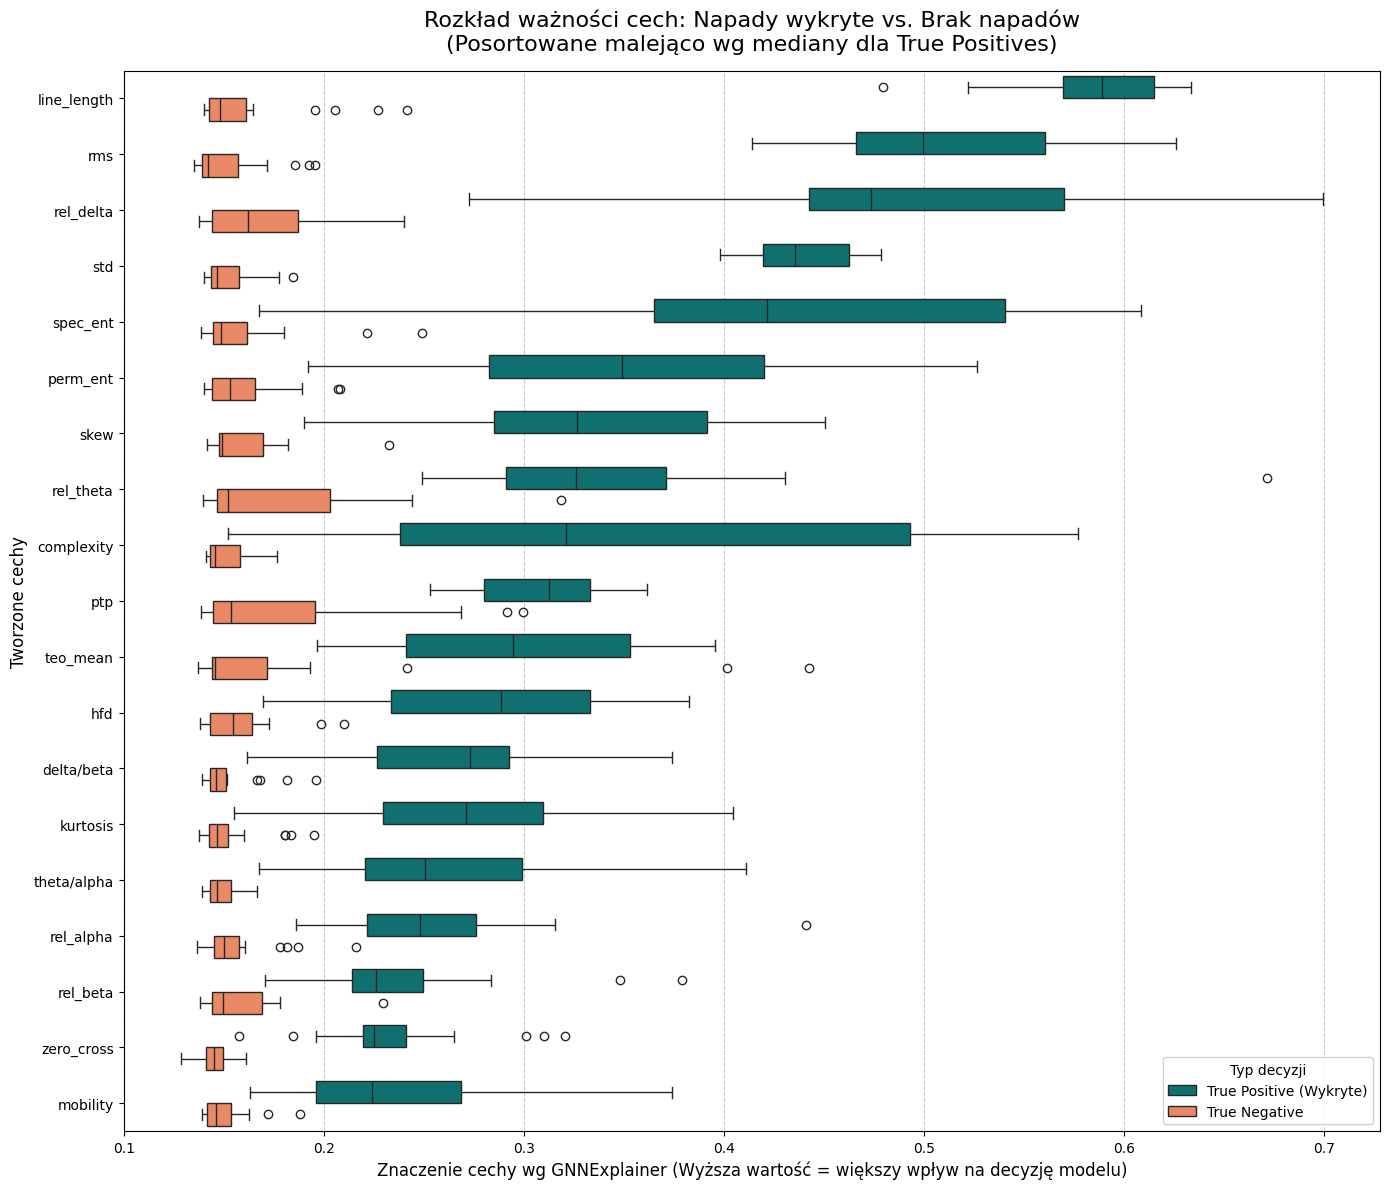

<Figure size 640x480 with 0 Axes>

In [47]:
# Wyciągamy tylko dane dla True Positives
df_tp = df[df['Typ decyzji'] == 'True Positive (Wykryte)']

# Obliczamy medianę ważności dla każdej cechy
medians = df_tp.groupby('Feature')['Importance'].median()

# Sortujemy cechy malejąco (od największej mediany do najmniejszej)
sorted_features = medians.sort_values(ascending=False).index.tolist()

# ==========================================
# Rysowanie posortowanych Boxplotów
# ==========================================
plt.figure(figsize=(14, 12)) # Lekko powiększony rozmiar dla lepszej czytelności

# Parametr 'order' wymusza naszą obliczoną kolejność na osi Y
sns.boxplot(
    data=df, 
    y='Feature', 
    x='Importance', 
    hue='Typ decyzji', 
    palette=['teal', 'coral'],
    order=sorted_features # <--- TUTAJ wstawiamy posortowaną listę
)

plt.title("Rozkład ważności cech: Napady wykryte vs. Brak napadów\n(Posortowane malejąco wg mediany dla True Positives)", fontsize=16, pad=15)
plt.xlabel("Znaczenie cechy wg GNNExplainer (Wyższa wartość = większy wpływ na decyzję modelu)", fontsize=12)
plt.ylabel("Tworzone cechy", fontsize=12)

# Dodatkowe elementy estetyczne
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title="Typ decyzji", loc='lower right', framealpha=0.9) # Przesuwamy legendę, żeby nie zasłaniała górnych (najważniejszych) słupków

plt.tight_layout()
plt.show()
plt.savefig(ROOT_DIR / "wyniki" / "gnn_explainer_tp_vs_tn_boxplot.png")

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Przygotowanie list
tp_importances, tn_importances = [], []
fp_importances, fn_importances = [], []
tp_count, tn_count, fp_count, fn_count = 0, 0, 0, 0
TARGET_SAMPLES = 50

# Konfiguracja Explainera (PyTorch Geometric 2.x)
explainer2 = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200), # 200 epok optymalizacji maski to standard
    explanation_type='model',           # Chcemy wyjaśnić decyzję modelu
    node_mask_type='attributes',        # Zwraca ważność poszczególnych cech (19 features)
    edge_mask_type=None,            # Zwraca ważność poszczególnych krawędzi (PLV)
    model_config=dict(
        mode='multiclass_classification',
        task_level='graph',             # Klasyfikujemy całe grafy (okna 6s), nie pojedyncze węzły
        return_type='raw',              # Twój model zwraca surowe logity (brak softmax na końcu forward)
    ),
)


# ==========================================
# FUNKCJA RATUNKOWA (Czyszczenie modelu)
# ==========================================
def cleanup_explain_state(model):
    """
    Usuwa pozostałości po GNNExplainerze z warstw modelu.
    Przywraca model do normalnego stanu forward pass.
    """
    for module in model.modules():
        if hasattr(module, 'explain'):
            module.explain = False
        if hasattr(module, '_edge_mask'):
            module._edge_mask = None

# # ==========================================
# # WŁAŚCIWA PĘTLA
# # ==========================================
# tp_importances = []
# tn_importances = []

# tp_count, tn_count = 0, 0
# TARGET_SAMPLES = 20 

import random

# Tworzymy przemieszaną kopię danych testowych
# random.sample(lista, k) zwraca nową listę o długości k z losowymi elementami
shuffled_test_data = random.sample(list(test_data), len(test_data))

for g in tqdm(shuffled_test_data, desc="Generowanie wyjaśnień"):
    if tp_count >= TARGET_SAMPLES and tn_count >= TARGET_SAMPLES and fp_count >= TARGET_SAMPLES and fn_count >= TARGET_SAMPLES: 
        break
    
    g = g.to(DEVICE)
    
    if hasattr(g, 'batch') and g.batch is None:
        g.batch = torch.zeros(g.num_nodes, dtype=torch.long, device=DEVICE)
        
    # Upewniamy się, że model jest czysty przed standardową predykcją
    cleanup_explain_state(model)
    

    # 1. Zwykła predykcja
    out = model(g.x, g.edge_index, g.batch, edge_weight=g.edge_attr)
    pred = out.argmax(dim=1).item()
    true_label = g.y.item()
    
    # Kategoryzacja do macierzy pomyłek
    category = None
    if true_label == 1 and pred == 1 and tp_count < TARGET_SAMPLES:
        category = 'TP'
    elif true_label == 1 and pred == 0 and fn_count < TARGET_SAMPLES:
        category = 'FN'
    elif true_label == 0 and pred == 0 and tn_count < TARGET_SAMPLES:
        category = 'TN'
    elif true_label == 0 and pred == 1 and fp_count < TARGET_SAMPLES:
        category = 'FP'
        
    if category is not None:
        try:
            # Puszczamy explainera (pamiętaj o użyciu explainer2 bez krawędzi!)
            explanation = explainer2(g.x, g.edge_index, batch=g.batch, edge_weight=g.edge_attr)
            global_feat_imp = explanation.node_mask.cpu().numpy().mean(axis=0)
            
            if category == 'TP':
                tp_importances.append(global_feat_imp)
                tp_count += 1
            elif category == 'FN':
                fn_importances.append(global_feat_imp)
                fn_count += 1
            elif category == 'TN':
                tn_importances.append(global_feat_imp)
                tn_count += 1
            elif category == 'FP':
                fp_importances.append(global_feat_imp)
                fp_count += 1
                
            print(f"Zebrano: TP:{tp_count}, FN:{fn_count}, TN:{tn_count}, FP:{fp_count}")
        except Exception as e:
            cleanup_explain_state(model)
            continue

print(f"Zebrano: TP:{tp_count}, FN:{fn_count}, TN:{tn_count}, FP:{fp_count}")

# Zbieranie danych do DataFrame
data = []
categories_map = {
    'TP': (tp_importances, 'True Positive (Wykryty napad)'),
    'FN': (fn_importances, 'False Negative (Przegapiony napad)'),
    'TN': (tn_importances, 'True Negative (Poprawny spoczynek)'),
    'FP': (fp_importances, 'False Positive (Fałszywy alarm)')
}

for cat_code, (importances, label) in categories_map.items():
    for feats in importances:
        for i, imp in enumerate(feats):
            data.append({'Feature': feature_names[i], 'Importance': imp, 'Typ decyzji': label})

df = pd.DataFrame(data)

# Sortowanie po medianie TP (bardzo ważne przy 4 kategoriach!)
df_tp = df[df['Typ decyzji'] == 'True Positive (Wykryty napad)']
sorted_features = df_tp.groupby('Feature')['Importance'].median().sort_values(ascending=False).index.tolist()

Generowanie wyjaśnień:   0%|          | 0/8603 [00:00<?, ?it/s]

Generowanie wyjaśnień:   0%|          | 1/8603 [00:03<8:34:33,  3.59s/it]

Zebrano: TP:0, FN:0, TN:1, FP:0


Generowanie wyjaśnień:   0%|          | 2/8603 [00:07<8:31:47,  3.57s/it]

Zebrano: TP:1, FN:0, TN:1, FP:0


...

Zebrano: TP:50, FN:50, TN:50, FP:42


Generowanie wyjaśnień:  94%|█████████▎| 8052/8603 [12:11<00:56,  9.76it/s]

Zebrano: TP:50, FN:50, TN:50, FP:43


Generowanie wyjaśnień: 100%|██████████| 8603/8603 [12:17<00:00, 11.66it/s] 

Zebrano: TP:50, FN:50, TN:50, FP:43


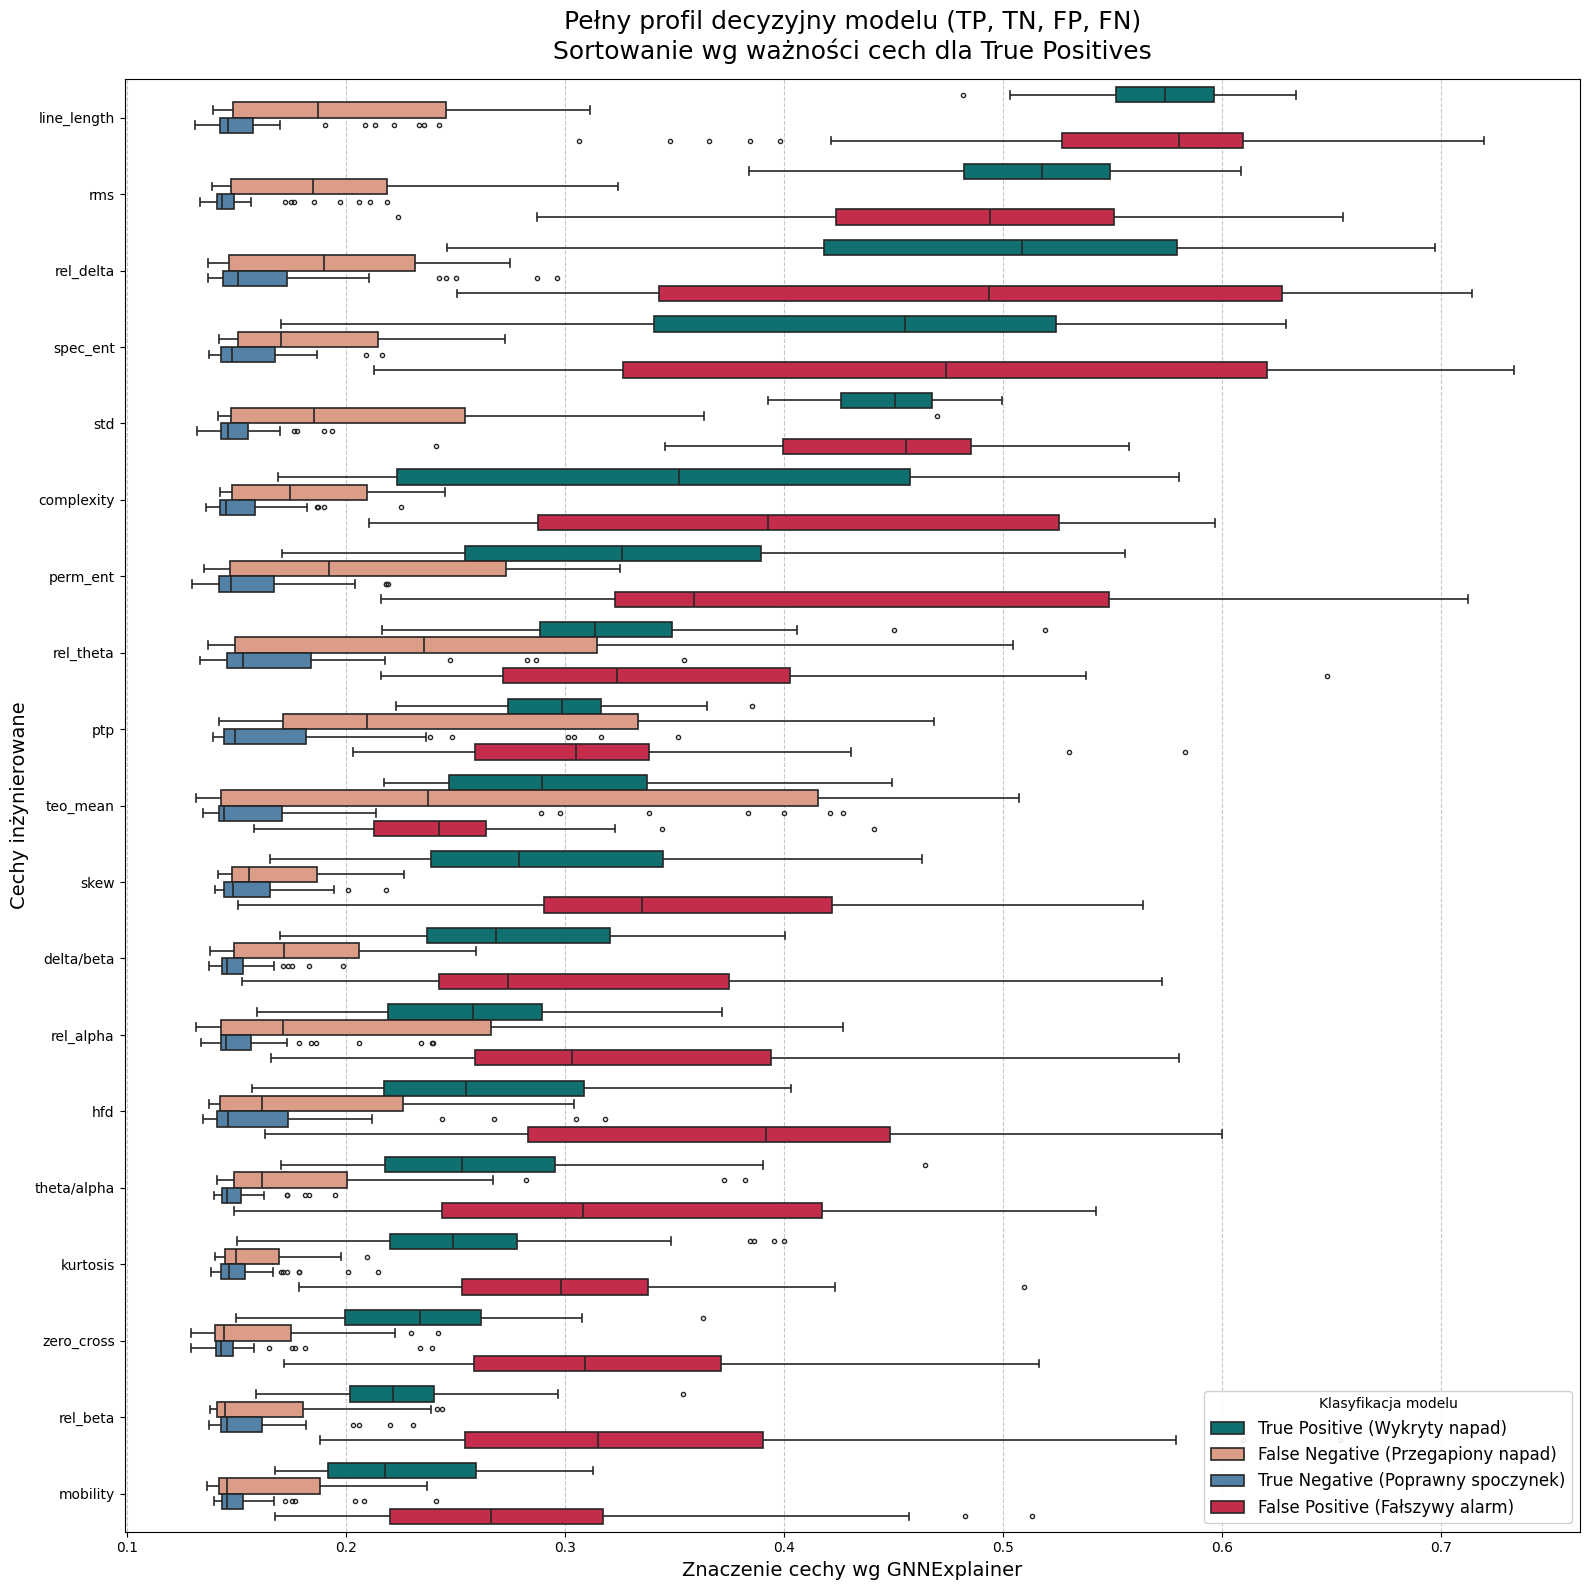

<Figure size 640x480 with 0 Axes>

In [49]:
# Rysowanie!
plt.figure(figsize=(16, 16)) # Większy rozmiar, żeby pomieścić 76 boxów!

# Używamy czytelnej palety 4 kolorów
palette = {
    'True Positive (Wykryty napad)': '#008080',      # Turkusowy (Dobrze)
    'False Negative (Przegapiony napad)': '#E9967A', # Koralowy (Źle)
    'True Negative (Poprawny spoczynek)': '#4682B4', # Stalowo-niebieski (Dobrze)
    'False Positive (Fałszywy alarm)': '#DC143C'     # Karmazynowy (Źle)
}

sns.boxplot(
    data=df, y='Feature', x='Importance', hue='Typ decyzji', 
    palette=palette, order=sorted_features, linewidth=1.2, fliersize=3
)

plt.title("Pełny profil decyzyjny modelu (TP, TN, FP, FN)\nSortowanie wg ważności cech dla True Positives", fontsize=18, pad=15)
plt.xlabel("Znaczenie cechy wg GNNExplainer", fontsize=14)
plt.ylabel("Cechy inżynierowane", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title="Klasyfikacja modelu", loc='lower right', framealpha=0.9, fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig(ROOT_DIR / "wyniki" / "gnn_explainer_full_confusion_boxplot.png")